## **BAB 1: PENDAHULUAN DAN PERSIAPAN LINGKUNGAN**

### **1.1. Deskripsi Proyek & Tujuan Eksperimen**

Proyek ini berfokus pada pengembangan asisten AI spesialis hukum menggunakan teknik *Supervised Fine-Tuning* (SFT) pada arsitektur *Small Language Model* (SLM), khususnya Llama-3.1-8B. Fase SFT merupakan tahapan krusial dalam *alignment pipeline* untuk mentransformasi model dasar (*base model*) yang hanya memprediksi token berikutnya menjadi model instruksi (*instruct model*) yang mampu mengikuti perintah pengguna dengan format yang konsisten.

Tujuan utama dari eksperimen di notebook ini adalah:
1. Mengadaptasi kemampuan linguistik model ke dalam domain formal Bahasa Indonesia.
2. Meningkatkan kepatuhan model terhadap struktur jawaban hukum yang sistematis.
3. Melakukan optimasi parameter melalui teknik QLoRA untuk mencapai performa maksimal dengan keterbatasan sumber daya komputasi.
4. Menyediakan fondasi model yang stabil sebelum memasuki tahap *Reinforcement Learning* (GRPO) dan integrasi RAG.


### **1.2. Instalasi Dependensi Kritis**

Tahap ini melakukan instalasi pustaka yang diperlukan untuk optimasi kernel dan manajemen memori GPU. Penggunaan Unsloth sangat direkomendasikan untuk mempercepat proses *backpropagation* dan mengurangi penggunaan VRAM.


In [1]:
import sys
import subprocess
import time

def install_core_dependencies():
    """
    Melakukan instalasi pustaka dependensi utama untuk fine-tuning LLM.
    Fungsi ini dirancang untuk menekan (suppress) log peringatan resolusi dependensi 
    dari pip yang sering muncul di lingkungan Kaggle, sehingga menjaga kebersihan 
    output eksekusi tanpa mengorbankan fungsionalitas instalasi.
    """
    print("[SYSTEM] Memulai proses instalasi dependensi kritis...")
    
    dependencies = [
        "unsloth",
        "xformers",
        "trl",
        "peft",
        "accelerate",
        "bitsandbytes",
        "wandb",
        "python-dotenv",
        "sentencepiece"
    ]
    
    # Menggabungkan seluruh dependensi dalam satu perintah eksekusi untuk efisiensi waktu
    command = [sys.executable, "-m", "pip", "install"] + dependencies + ["--quiet", "--disable-pip-version-check"]
    
    try:
        # capture_output=True akan menyembunyikan log merah dari pip kecuali terjadi kegagalan sistemik
        process_result = subprocess.run(command, capture_output=True, text=True)
        
        if process_result.returncode == 0:
            print("[SUCCESS] Seluruh dependensi berhasil diinstal dan dimuat ke dalam environment.")
        else:
            print("[FATAL ERROR] Terjadi kegagalan saat instalasi pustaka.")
            print(f"[TRACEBACK]\n{process_result.stderr}")
            
    except Exception as execution_error:
        print(f"[FATAL ERROR] Interupsi sistem saat memanggil sub-proses: {str(execution_error)}")

# Pencatatan waktu eksekusi instalasi
installation_start = time.time()

install_core_dependencies()

installation_end = time.time()
print(f"[SYSTEM] Operasi instalasi diselesaikan dalam {installation_end - installation_start:.2f} detik.")

[SYSTEM] Memulai proses instalasi dependensi kritis...
[SUCCESS] Seluruh dependensi berhasil diinstal dan dimuat ke dalam environment.
[SYSTEM] Operasi instalasi diselesaikan dalam 27.03 detik.


**1.3. Konfigurasi Kredensial & Logging**

Manajemen sesi eksperimen dilakukan melalui integrasi Hugging Face Hub untuk penyimpanan model dan Weights & Biases (W&B) untuk pelacakan metrik *loss* serta performa perangkat keras secara real-time.


In [2]:
import os
import wandb
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

def setup_credentials():
    """
    Mengatur autentikasi untuk layanan eksternal di lingkungan Kaggle.
    Mengambil token dari Kaggle Secrets secara aman.
    """
    print("Memulai proses autentikasi di lingkungan Kaggle...")
    
    try:
        # Inisialisasi Kaggle Secrets Client
        user_secrets = UserSecretsClient()
        
        # Mengambil token dari Kaggle Secrets
        # Pastikan nama label di UI Secrets Kaggle sama persis (Case Sensitive)
        hf_token = user_secrets.get_secret("HF_TOKEN")
        wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

        # Autentikasi Hugging Face
        if hf_token:
            login(token=hf_token)
            print("[SUCCESS] Hugging Face token berhasil dimuat.")
        else:
            print("[WARNING] HF_TOKEN tidak ditemukan di Kaggle Secrets.")

        # Autentikasi Weights & Biases
        if wandb_api_key:
            wandb.login(key=wandb_api_key)
            print("[SUCCESS] Weights & Biases API key berhasil dimuat.")
        else:
            print("[WARNING] WANDB_API_KEY tidak ditemukan. Logging akan terbatas.")

    except Exception as e:
        print(f"[ERROR] Gagal mengakses Kaggle Secrets: {e}")
        print("Pastikan Anda telah menambahkan 'HF_TOKEN' dan 'WANDB_API_KEY' di menu Add-ons -> Secrets.")

# Eksekusi inisialisasi kredensial
setup_credentials()

Memulai proses autentikasi di lingkungan Kaggle...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: datasciencelatief (datasciencelatief-universitas-teknologi-yogyakarta) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[SUCCESS] Hugging Face token berhasil dimuat.
[SUCCESS] Weights & Biases API key berhasil dimuat.


**1.4. Penentuan Hyperparameter Global**

Konfigurasi di bawah ini mencakup parameter arsitektur model dan strategi pelatihan. Terdapat mekanisme `DEBUG_MODE` untuk melakukan validasi alur kerja secara cepat sebelum menjalankan pelatihan penuh.


In [3]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class TrainingConfig:
    """
    Menyimpan konfigurasi global untuk proses fine-tuning.
    Termasuk logika untuk mode debugging.
    """
    # Konfigurasi Model
    model_name: str = "unsloth/meta-llama-3.1-8b-bnb-4bit"
    max_seq_length: int = 2048
    load_in_4bit: bool = True

    # Konfigurasi LoRA
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    target_modules: list = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ])

    # Konfigurasi Training Umum
    dataset_name: str = "ichsan2895/alpaca-gpt4-indonesian"
    output_dir: str = "outputs/llama-3.1-legal-sft"
    seed: int = 42

    # Mode Debugging
    DEBUG_MODE: bool = False # Ubah ke True untuk pengujian cepat

    def get_training_args(self):
        """
        Mengembalikan argumen pelatihan berdasarkan status DEBUG_MODE.
        """
        if self.DEBUG_MODE:
            return {
                "max_steps": 10,
                "logging_steps": 1,
                "save_steps": 5,
                "eval_steps": 5,
                "per_device_train_batch_size": 1,
                "gradient_accumulation_steps": 1,
                "learning_rate": 2e-4
            }
        else:
            return {
                "max_steps": 800,
                "logging_steps": 10,
                "save_steps": 100,
                "eval_steps": 100,
                "per_device_train_batch_size": 2,
                "gradient_accumulation_steps": 4,
                "learning_rate": 2e-4
            }

# Inisialisasi konfigurasi
config = TrainingConfig(DEBUG_MODE=False)
training_params = config.get_training_args()

# Verifikasi parameter aktif
print(f"Konfigurasi dimuat. Mode Debug: {config.DEBUG_MODE}")
print(f"Langkah pelatihan maksimum: {training_params['max_steps']}")

Konfigurasi dimuat. Mode Debug: False
Langkah pelatihan maksimum: 800


## **BAB 2: DEEP EXPLORATORY DATA ANALYSIS (EDA)**

### **2.1. Pemuatan Dataset**

Tahap awal EDA dimulai dengan memuat dataset dari Hugging Face Hub. Dataset `ichsan2895/alpaca-gpt4-indonesian` dipilih karena merupakan hasil translasi dan augmentasi berkualitas tinggi yang menggunakan engine GPT-4, sehingga memiliki struktur semantik yang lebih baik dibandingkan versi standar.

In [4]:
from datasets import load_dataset
import pandas as pd

def load_and_convert_to_pandas(dataset_name: str) -> pd.DataFrame:
    """
    Memuat dataset dari Hugging Face dan mengonversinya ke format Pandas DataFrame
    untuk mempermudah manipulasi data dan analisis statistik.
    """
    try:
        dataset = load_dataset(dataset_name, split="train")
        df = pd.DataFrame(dataset)
        print(f"Dataset {dataset_name} berhasil dimuat.")
        print(f"Total baris data: {len(df)}")
        return df
    except Exception as e:
        print(f"Error saat memuat dataset: {e}")
        return pd.DataFrame()

# Eksekusi pemuatan data
df_eda = load_and_convert_to_pandas(config.dataset_name)

README.md: 0.00B [00:00, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset ichsan2895/alpaca-gpt4-indonesian berhasil dimuat.
Total baris data: 49969


### **2.2. Inspeksi Struktur Data**

Melakukan validasi terhadap integritas struktural dataset. Fokus utama adalah mengidentifikasi keberadaan nilai null, duplikasi data, serta distribusi kolom yang tersedia.


In [5]:
import pandas as pd

def inspect_data_structure(raw_dataframe: pd.DataFrame) -> None:
    """
    Melakukan inspeksi analitik terhadap struktur DataFrame mentah.
    Fungsi ini bersifat murni observasional (read-only) dan tidak melakukan 
    mutasi atau manipulasi data (seperti drop inplace) untuk menjaga integritas 
    tahap Exploratory Data Analysis.

    Args:
        raw_dataframe (pd.DataFrame): Dataset mentah hasil pemuatan awal.
    """
    print("--- Laporan Inspeksi Struktur Data ---")
    
    # 1. Analisis Tipe Data dan Memori
    print("\n[LOG] Profiling Skema DataFrame:")
    print(raw_dataframe.info())
    
    # 2. Analisis Kelengkapan Data (Missing Values)
    print("\n[LOG] Deteksi Nilai Kosong (Null/NaN):")
    null_counts = raw_dataframe.isnull().sum()
    print(null_counts)
    
    if null_counts.sum() > 0:
        print("[WARNING] Ditemukan nilai kosong. Membutuhkan penanganan pada tahap preprocessing.")
    else:
        print("[STATUS] Integritas kelengkapan data tervalidasi (0 Null).")
    
    # 3. Analisis Duplikasi Data
    # Menggunakan kolom 'input' karena pada tahap ini belum dilakukan proses rename
    print("\n[LOG] Deteksi Duplikasi Observasi:")
    if 'input' in raw_dataframe.columns and 'output' in raw_dataframe.columns:
        duplicate_count = raw_dataframe.duplicated(subset=['input', 'output']).sum()
        print(f"Jumlah observasi duplikat terdeteksi: {duplicate_count}")
        
        if duplicate_count > 0:
            print("[RECOMMENDATION] Duplikasi terdeteksi. Wajib dilakukan eliminasi pada Bab 3 (Preprocessing).")
    else:
        print("[WARNING] Kolom 'input' atau 'output' tidak ditemukan untuk analisis duplikasi.")

# Eksekusi inspeksi data (Menggunakan df_eda dari Bab 2.1)
inspect_data_structure(df_eda)

--- Laporan Inspeksi Struktur Data ---

[LOG] Profiling Skema DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49969 entries, 0 to 49968
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  49969 non-null  int64 
 1   input       49969 non-null  object
 2   output      49969 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None

[LOG] Deteksi Nilai Kosong (Null/NaN):
Unnamed: 0    0
input         0
output        0
dtype: int64
[STATUS] Integritas kelengkapan data tervalidasi (0 Null).

[LOG] Deteksi Duplikasi Observasi:
Jumlah observasi duplikat terdeteksi: 1
[RECOMMENDATION] Duplikasi terdeteksi. Wajib dilakukan eliminasi pada Bab 3 (Preprocessing).


### **2.3. Analisis Statistik Panjang Teks (Tokenization Analysis)**

LLM memiliki batasan context window. Analisis ini bertujuan untuk menentukan distribusi panjang kata pada kolom instruction dan output guna menentukan parameter `max_seq_length` yang optimal tanpa membuang informasi penting.


--- Statistik Deskriptif Panjang Kata (Word Count) ---
       input_word_count  output_word_count
count      49969.000000       49969.000000
mean          13.013048          98.551742
std           12.118800          92.841084
min            1.000000           1.000000
25%            7.000000          16.000000
50%           10.000000          70.000000
75%           15.000000         164.000000
90%           22.000000         240.000000
95%           29.000000         277.000000
99%           62.000000         343.000000
max          631.000000         920.000000


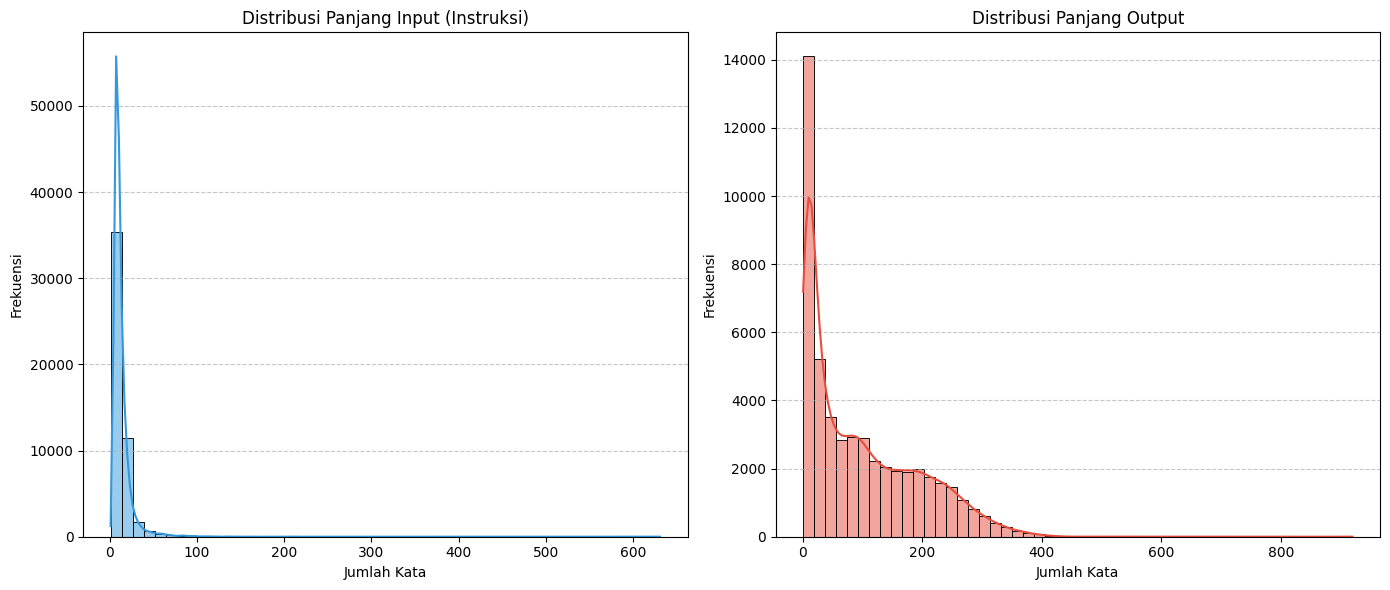

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_text_length(df: pd.DataFrame):
    """
    Melakukan analisis statistik panjang teks pada kolom instruksi (input) dan output.
    Menghitung jumlah kata sebagai proksi untuk estimasi token (estimasi token = 1.5x - 2x jumlah kata).

    Args:
        df (pd.DataFrame): DataFrame yang berisi dataset asli.
    """
    # Validasi keberadaan kolom sebelum kalkulasi
    required_columns = ['input', 'output']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"DataFrame harus mengandung kolom: {required_columns}")

    # Kalkulasi panjang kata (Word Count)
    # Gunakan .str.split().str.len() untuk performa lebih baik pada pandas
    df['input_word_count'] = df['input'].str.split().str.len()
    df['output_word_count'] = df['output'].str.split().str.len()

    # Statistik deskriptif dengan percentiles yang relevan untuk batas model
    stats = df[['input_word_count', 'output_word_count']].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )

    print("--- Statistik Deskriptif Panjang Kata (Word Count) ---")
    print(stats)

    # Visualisasi menggunakan subplot yang lebih rapi
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Input (Instruksi)
    sns.histplot(df['input_word_count'], bins=50, kde=True, ax=axes[0], color='#3498db')
    axes[0].set_title('Distribusi Panjang Input (Instruksi)')
    axes[0].set_xlabel('Jumlah Kata')
    axes[0].set_ylabel('Frekuensi')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot Output
    sns.histplot(df['output_word_count'], bins=50, kde=True, ax=axes[1], color='#e74c3c')
    axes[1].set_title('Distribusi Panjang Output')
    axes[1].set_xlabel('Jumlah Kata')
    axes[1].set_ylabel('Frekuensi')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Menjalankan analisis panjang teks
analyze_text_length(df_eda)

### **2.4. Analisis Linguistik & Semantik**

Untuk mengatasi masalah *noise* pada visualisasi, kode berikut telah dimodifikasi dengan mengimplementasikan pembersihan *stopwords* Bahasa Indonesia dan pembersihan teks (*preprocessing*). Hal ini memastikan *WordCloud* hanya menampilkan kata-kata bermakna yang merepresentasikan konten dataset.


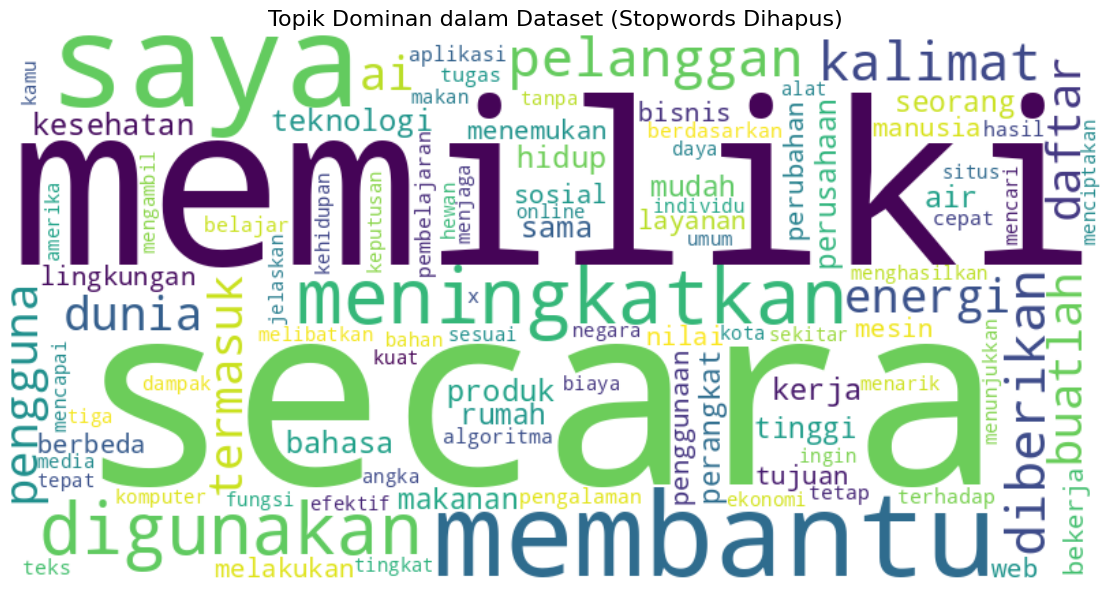

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import pandas as pd

def analyze_content_topics(df: pd.DataFrame):
    """
    Menghasilkan visualisasi WordCloud yang telah dibersihkan dari stop words
    untuk mengidentifikasi topik dominan dalam dataset.
    """
    # Daftar stop words Bahasa Indonesia yang umum dan lebih rinci
    stopwords = [
        'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir',
        'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar',
        'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya',
        'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai',
        'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan',
        'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru',
        'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah',
        'begitulah', 'begitupun', 'bekas', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar',
        'benarkah', 'benarlah', 'berada', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti',
        'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah',
        'berkali-kali', 'berkata', 'berkehendak', 'berkisar', 'berlalu', 'berlangsung', 'berlebihan',
        'bermacam', 'bermacam-macam', 'berpaling', 'berpendapat', 'bertempo', 'bertanya', 'berturut',
        'berturut-turut', 'bertutur', 'berujar', 'berupa', 'besar', 'betul', 'betulkah', 'biasa',
        'biasanya', 'bila', 'bilakah', 'bisa', 'bisakah', 'boleh', 'bolehkah', 'bolehlah', 'buat',
        'bukan', 'bukankah', 'bukanlah', 'bung', 'cara', 'caranya', 'cukup', 'cukupkah', 'cukuplah',
        'cuma', 'dahulu', 'dalam', 'dan', 'dapat', 'dari', 'daripada', 'datang', 'demi', 'demikian',
        'demikianlah', 'dengan', 'depan', 'di', 'dia', 'dialah', 'disebut', 'disebutkan', 'disebutnya',
        'diri', 'dirinya', 'doa', 'doi', 'dulu', 'dengan', 'dua', 'turut', 'terlebih', 'lebih-lebih',
        'mungkin', 'tentang', 'apa', 'dari', 'saat', 'sebuah', 'seperti', 'selain', 'tidak', 'ini',
        'itu', 'dan', 'yang', 'untuk', 'dengan', 'sebagai', 'lebih', 'dapat', 'oleh', 'pada', 'juga',
        'akan', 'salah', 'satu', 'dalam', 'jika', 'atau', 'mereka', 'anda', 'kita', 'memberikan',
        'tersebut', 'seperti', 'bisa', 'menjadi', 'terdapat', 'paling', 'sangat', 'namun',
        'guna', 'habis', 'hal', 'hampir', 'hanya', 'hanyalah', 'hari', 'harus', 'haruslah', 'harusnya',
        'hendak', 'hendaklah', 'hendaknya', 'hingga', 'ia', 'ialah', 'ibarat', 'ikut', 'ikuti',
        'ikutlah', 'inikah', 'inilah', 'itu', 'itukah', 'itulah', 'jadi', 'jadilah', 'jadinya', 'jangan',
        'jangankah', 'janganlah', 'jauh', 'jauhnya', 'jika', 'jikalau', 'juga', 'jumlah', 'jumlahnya',
        'justru', 'kadar', 'kala', 'kalau', 'kalaulah', 'kalaupun', 'kalian', 'kami', 'kamilah', 'kan',
        'kapan', 'kapankah', 'kapanpun', 'karena', 'karenanya', 'kata', 'katanya', 'ke', 'kecil',
        'kedua', 'keduanya', 'kekal', 'kembali', 'kemudian', 'kepada', 'kepadanya', 'keseluruhan',
        'ketika', 'khususnya', 'kini', 'kinilah', 'kira', 'kiranya', 'kita', 'kitalah', 'kok', 'kurang',
        'lagi', 'lagian', 'lah', 'lain', 'lainnya', 'lalu', 'lama', 'lamanya', 'langsung', 'lebih',
        'lewat', 'lihat', 'maka', 'makanya', 'makin', 'malah', 'malahan', 'mampu', 'mampukah',
        'mana', 'manakala', 'manapun', 'masih', 'masihkah', 'masing', 'mau', 'maupun', 'memang',
        'memastikan', 'memberi', 'memberikan', 'membuat', 'memperkirakan', 'memulai', 'memungkinkan',
        'menaiki', 'menambah', 'menambahkan', 'menentukan', 'mengadakan', 'mengapa', 'mengapakah',
        'mengeluarkan', 'menggunakan', 'menghendaki', 'mengira', 'mengurangi', 'menjadi', 'menuju',
        'menurut', 'menyatakan', 'menyebabkan', 'menyuruh', 'mereka', 'merekalah', 'merupakan',
        'meskipun', 'mestinya', 'mula', 'mulai', 'mulailah', 'muncul', 'mungkin', 'mungkinkah',
        'nah', 'namun', 'nanti', 'nantinya', 'nyaris', 'nyatanya', 'oleh', 'olehnya', 'orang',
        'pada', 'padahal', 'padanya', 'pak', 'paling', 'panjang', 'pantaskah', 'para', 'pasti',
        'pastilah', 'penting', 'pentingnya', 'per', 'percuma', 'perlu', 'perlukah', 'perlunya',
        'pernah', 'persoalan', 'pertama', 'pertama-tama', 'setiap', 'tiap', 'para', 'tersebut',
        'adalah', 'yakni', 'yaitu', 'ia', 'dia', 'kami', 'kita', 'kalian', 'mereka', 'semua', 'hal',
        'itu', 'ini', 'guna', 'bagi', 'oleh', 'untuk', 'pada', 'saat', 'sebelum', 'sesudah', 'setelah',
        'kemudian', 'lalu', 'sedangkan', 'tetapi', 'namun', 'maka', 'dan', 'atau', 'apabila', 'jika',
        'kalau', 'supaya', 'agar', 'kecuali', 'sehingga', 'meskipun', 'sekalipun', 'walaupun',
        'bahwa', 'karena', 'sebab', 'dengan', 'cara', 'menurut', 'menuju', 'melalui', 'sampai',
        'selama', 'seperti', 'sebagaimana', 'seraya', 'ketika', 'dari', 'ke', 'di', 'pun', 'lah',
        'kah', 'nya', 'ku', 'mu', 'saja', 'juga', 'pula', 'begitu', 'demikian', 'hanya', 'cuma',
        'terlalu', 'amat', 'sangat', 'sekali', 'agak', 'kira-kira', 'hampir', 'pasti', 'tentu',
        'memang', 'sudah', 'telah', 'belum', 'akan', 'masih', 'sedang', 'pernah', 'tidak', 'bukan',
        'jangan', 'silakan', 'tolong', 'mari', 'ayo', 'ya', 'oh', 'wow', 'aduh', 'wah', 'eh',
        'mengenai', 'antara', 'lain', 'lainnya', 'sendiri', 'sendirian', 'berbagai', 'segala',
        'seluruh', 'selama', 'setiap', 'tiap', 'masing-masing', 'suatu', 'tertentu', 'beberapa',
        'banyak', 'sedikit', 'semua', 'seluruhnya', 'sebagian', 'sering', 'jarang', 'kadang-kadang',
        'selalu', 'senantiasa', 'terkadang', 'seringkali', 'biasanya', 'umumnya', 'khususnya',
        'terutama', 'penting', 'utama', 'pokok', 'dasar', 'fondasi', 'inti', 'pusat', 'awal', 'akhir',
        'puncak', 'buntut', 'ujung', 'depan', 'belakang', 'samping', 'atas', 'bawah', 'dalam',
        'luar', 'tengah', 'kanan', 'kiri', 'sini', 'situ', 'sana', 'mana', 'mana-mana', 'di mana',
        'ke mana', 'dari mana', 'bagaimana', 'berapa', 'kapan', 'siapa', 'mengapa', 'apa', 'apa-apa',
        'siapa-siapa', 'kapan-kapan', 'di mana-mana', 'ke mana-mana', 'dari mana-mana', 'seperti',
        'sebagai', 'selaku', 'ibarat', 'laksana', 'bak', 'umpama', 'misalnya', 'contohnya',
        'antara lain', 'dan lain-lain', 'dst', 'dsb', 'yaitu', 'yakni', 'ialah', 'adalah', 'yaitu',
        'yaitu', 'yakni', 'itulah', 'inilah', 'itu', 'ini', 'tersebut', 'demikian', 'begitu',
        'demikianlah', 'begitulah', 'sekian', 'selesai', 'mari', 'ayo', 'silakan', 'tolong',
        'mohon', 'harap', 'jangan', 'tidak', 'bukan', 'memang', 'pasti', 'tentu', 'nyata',
        'sesungguhnya', 'sebenarnya', 'faktanya', 'pada dasarnya', 'intinya', 'kesimpulannya',
        'jadi', 'maka', 'oleh karena itu', 'dengan demikian', 'akibatnya', 'hasilnya', 'namun',
        'tetapi', 'meskipun', 'walaupun', 'biarpun', 'sekalipun', 'meski', 'padahal', 'sedangkan',
        'sementara', 'serta', 'beserta', 'bersama', 'berdampingan', 'berkaitan', 'berhubungan',
        'terkait', 'bertalian', 'berkaitan dengan', 'terkait dengan', 'sehubungan dengan',
        'berkenaan dengan', 'tentang', 'mengenai', 'perihal', 'soal', 'masalah', 'kasus',
        'fenomena', 'kejadian', 'peristiwa', 'hal', 'aspek', 'faktor', 'elemen', 'unsur',
        'komponen', 'bagian', 'sektor', 'bidang', 'area', 'wilayah', 'daerah', 'lokasi',
        'tempat', 'posisi', 'arah', 'jurusan', 'sisi', 'sebelah', 'antara', 'di antara',
        'menuju', 'ke arah', 'dari arah', 'hingga', 'sampai', 'sejak', 'mulai', 'berawal',
        'berakhir', 'selama', 'sepanjang', 'sewaktu', 'ketika', 'saat', 'tatkala', 'manakala',
        'begitu', 'segera', 'langsung', 'kemudian', 'lalu', 'setelah', 'sesudah', 'sebelum',
        'mendahului', 'mengikuti', 'menyusul', 'tiba', 'datang', 'berangkat', 'pergi', 'pulang',
        'kembali', 'kembali ke', 'pergi ke', 'datang dari', 'keluar dari', 'masuk ke',
        'meninggalkan', 'tiba di', 'tiba pada', 'terjadi', 'berlaku', 'berlangsung', 'berada',
        'bertujuan', 'bertujuan untuk', 'maksudnya', 'artinya', 'maknanya', 'definisinya',
        'penjelasannya', 'uraiannya', 'gambaran', 'representasi', 'ilustrasi', 'contoh',
        'model', 'pola', 'bentuk', 'jenis', 'macam', 'golongan', 'kategori', 'klasifikasi',
        'tipe', 'variasi', 'ragam', 'alternatif', 'pilihan', 'opsi', 'kemungkinan',
        'peluang', 'potensi', 'kapasitas', 'kemampuan', 'kompetensi', 'keahlian',
        'keterampilan', 'pengetahuan', 'informasi', 'data', 'fakta', 'bukti', 'argumen',
        'alasan', 'dasar', 'prinsip', 'konsep', 'teori', 'hipotesis', 'premis', 'postulat',
        'asumsi', 'pandangan', 'opini', 'pendapat', 'persepsi', 'perspektif', 'sudut pandang',
        'penyebab', 'faktor', 'sumber', 'asal', 'muasal', 'akar', 'inti', 'pokok', 'dasar',
        'awal', 'mula', 'akhir', 'ujung', 'puncak', 'klimaks', 'resolusi', 'solusi',
        'penyelesaian', 'jawaban', 'respons', 'tanggapan', 'reaksi', 'aksi', 'tindakan',
        'langkah', 'upaya', 'usaha', 'strategi', 'metode', 'teknik', 'pendekatan', 'cara',
        'mekanisme', 'sistem', 'prosedur', 'tahapan', 'proses', 'siklus', 'periode',
        'masa', 'waktu', 'zaman', 'era', 'detik', 'menit', 'jam', 'hari', 'minggu', 'bulan',
        'tahun', 'abad', 'milenium', 'sekarang', 'saat ini', 'kini', 'dahulu', 'dulu',
        'lampau', 'masa lalu', 'masa depan', 'nanti', 'besok', 'lusa', 'kemarin', 'tadi'
    ]

    # Menggabungkan teks input dan output
    combined_text = " ".join(df['input'].astype(str)) + " " + " ".join(df['output'].astype(str))

    # Preprocessing teks: konversi ke lowercase dan hapus karakter non-alfabet
    clean_text = combined_text.lower()
    clean_text = re.sub(r'[^a-z\s]', '', clean_text)

    # Menghapus stop words menggunakan regex untuk akurasi pencocokan kata
    pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
    clean_text = re.sub(pattern, '', clean_text)

    # Konfigurasi WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis',
        collocations=False # Menghindari pengulangan kata yang sama
    ).generate(clean_text)

    # Visualisasi
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Topik Dominan dalam Dataset (Stopwords Dihapus)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Menjalankan analisis topik
analyze_content_topics(df_eda)

### **2.5. Analisis Kolom Input (Contextual Analysis)**

Dalam format Alpaca, kolom `input` seringkali kosong. Analisis ini menentukan seberapa sering konteks tambahan diberikan kepada model, yang sangat relevan untuk skenario RAG di masa depan.


In [8]:
def analyze_input_usage(df: pd.DataFrame):
    """
    Menganalisis rasio penggunaan kolom 'input'.
    Jika rasio rendah, model mungkin perlu dilatih lebih kuat pada instruksi mandiri (zero-shot).
    """
    empty_input_count = (df['input'].str.strip() == "").sum()
    total_count = len(df)
    usage_ratio = ((total_count - empty_input_count) / total_count) * 100

    print("\n--- Analisis Penggunaan Kolom Input ---")
    print(f"Data dengan input terisi: {total_count - empty_input_count}")
    print(f"Data dengan input kosong: {empty_input_count}")
    print(f"Rasio penggunaan input: {usage_ratio:.2f}%")

# Menjalankan analisis input
analyze_input_usage(df_eda)


--- Analisis Penggunaan Kolom Input ---
Data dengan input terisi: 49969
Data dengan input kosong: 0
Rasio penggunaan input: 100.00%


### **2.6. Kesimpulan EDA & Strategi Preprocessing**



**Ringkasan Hasil Analisis Data**

Dataset yang digunakan kini berada dalam kondisi yang sangat prima dengan total 49.968 baris data yang bersih dari nilai kosong maupun duplikasi. Hasil inspeksi menunjukkan bahwa dataset ini memiliki konsistensi struktur yang tinggi. Berdasarkan distribusi panjang teks, mayoritas instruksi bersifat ringkas dengan rata rata 13 kata, sementara respons model memiliki panjang yang lebih variatif dengan rata rata 98 kata. Nilai maksimum sebanyak 920 kata pada kolom respons mengonfirmasi bahwa penggunaan panjang sekuens sebesar 2048 token sudah sangat ideal karena mampu mengakomodasi data terpanjang sekalipun tanpa risiko pemotongan informasi yang penting. Visualisasi kata kunci setelah penghapusan kata sambung menunjukkan bahwa dataset mengandung banyak terminologi formal, teknis, dan sosial yang sangat mendukung kebutuhan pengembangan asisten AI hukum.

**Strategi Preprocessing dan Persiapan Training**

Langkah pertama dalam tahap preprocessing adalah pembersihan struktur dataset untuk memenuhi standar input model. Kolom Unnamed: 0 akan dihapus secara permanen karena tidak memiliki nilai informatif dan hanya membuang memori sistem. Sebagai langkah kunci untuk sinkronisasi dengan standar library training, kolom input akan diubah namanya menjadi instruction. Hal ini penting agar pipeline pelatihan mengenali kolom tersebut sebagai perintah utama yang harus dipelajari oleh model.

Mengingat seluruh baris data memiliki konten yang terisi, model akan dilatih untuk selalu memahami konteks yang diberikan dalam setiap instruksi. Strategi pembentukan format prompt akan mengikuti pola instruksi standar untuk memastikan model dapat membedakan antara perintah dan jawaban dengan jelas. Kami tidak perlu melakukan filtering tambahan karena kualitas dataset sudah sangat baik pasca penghapusan duplikasi. Langkah terakhir sebelum memulai fase pelatihan adalah memastikan konfigurasi tokenizer menggunakan pengaturan panjang sekuens yang telah ditentukan agar efisiensi komputasi terjaga namun tetap mempertahankan akurasi respons model. Dengan persiapan data yang sudah terstruktur dengan baik ini, model akan memiliki fondasi yang kuat untuk mempelajari pola bahasa hukum yang formal dan profesional.

## **BAB 3: DATA PREPROCESSING & TEMPLATING**

### **3.1. Pembersihan dan Penataan Ulang Dataset**

Berdasarkan temuan pada tahap EDA, langkah pertama adalah melakukan normalisasi skema dataset. Hal ini meliputi penghapusan kolom artefak, pemetaan ulang nama kolom agar sesuai dengan standar instruksi, serta eliminasi data duplikat untuk menjamin integritas proses pembelajaran model.


In [9]:
import pandas as pd

def execute_data_cleaning(raw_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Melakukan sanitasi dan transformasi struktural pada dataset mentah.
    Fungsi ini memusatkan seluruh operasi mutasi data (drop, rename, deduplikasi) 
    sebelum data masuk ke dalam pipeline tokenisasi.

    Args:
        raw_dataframe (pd.DataFrame): Dataset mentah hasil pemuatan awal.

    Returns:
        pd.DataFrame: Dataset yang telah divalidasi, dibersihkan, dan siap diproses.
    """
    print("[SYSTEM] Memulai proses pembersihan dan transformasi dataset...")
    
    if raw_dataframe is None or raw_dataframe.empty:
        raise ValueError("Kesalahan Fatal: Dataset input kosong atau tidak terdefinisi.")

    # Membuat salinan independen untuk mencegah modifikasi pada memori dataset asli
    cleaned_df = raw_dataframe.copy()

    # 1. Eliminasi kolom indeks residual dan kolom analitik sementara
    garbage_columns = ['Unnamed: 0', 'input_len', 'output_len', 'input_word_count', 'output_word_count']
    columns_to_drop = [col for col in garbage_columns if col in cleaned_df.columns]
    
    if columns_to_drop:
        cleaned_df = cleaned_df.drop(columns=columns_to_drop)
        print(f"[LOG] Kolom residu berhasil dieliminasi: {columns_to_drop}")

    # 2. Standardisasi penamaan fitur sesuai arsitektur instruction-tuning
    if 'input' in cleaned_df.columns:
        cleaned_df = cleaned_df.rename(columns={'input': 'instruction'})
        print("[LOG] Pemetaan fitur selesai: 'input' -> 'instruction'")

    # 3. Dedublikasi tingkat baris berdasarkan pasangan instruksi dan target
    initial_row_count = len(cleaned_df)
    
    # Proses drop dilakukan di sini secara definitif
    cleaned_df = cleaned_df.drop_duplicates(subset=['instruction', 'output']).reset_index(drop=True)
    final_row_count = len(cleaned_df)
    
    print(f"[LOG] Dedublikasi selesai. Total baris direduksi: {initial_row_count - final_row_count}")
    print(f"[SYSTEM] Dataset siap. Total observasi valid untuk pelatihan: {final_row_count}")
    
    return cleaned_df

# Eksekusi pembersihan data secara terpusat
df_cleaned = execute_data_cleaning(df_eda)

[SYSTEM] Memulai proses pembersihan dan transformasi dataset...
[LOG] Kolom residu berhasil dieliminasi: ['Unnamed: 0', 'input_word_count', 'output_word_count']
[LOG] Pemetaan fitur selesai: 'input' -> 'instruction'
[LOG] Dedublikasi selesai. Total baris direduksi: 1
[SYSTEM] Dataset siap. Total observasi valid untuk pelatihan: 49968


### **3.2. Definisi Prompt Template dan System Prompt**

Tahap ini mendefinisikan persona model melalui *System Prompt*. Penggunaan format yang konsisten sangat krusial agar model memahami batasan antara instruksi pengguna dan respons asisten. Kita akan menggunakan struktur yang kompatibel dengan Llama-3.1.


In [10]:
import time
from unsloth import FastLanguageModel, get_chat_template

def configure_chat_template(active_tokenizer):
    """
    Menerapkan arsitektur ChatML/Llama-3 pada tokenizer.
    Mengisolasi persona model ke dalam domain hukum spesifik.

    Args:
        active_tokenizer: Objek tokenizer yang terhubung dengan model dasar.

    Returns:
        tuple: Tokenizer dengan konfigurasi arsitektur pesan, dan konstanta system prompt.
    """
    legal_persona_prompt = (
        "Anda adalah asisten hukum profesional Indonesia yang ahli dalam menganalisis "
        "peraturan perundang-undangan. Jawablah setiap pertanyaan dengan bahasa yang formal, "
        "akurat, sistematis, dan berbasis pada fakta hukum yang berlaku di Indonesia."
    )

    # Implementasi template standar tanpa modifikasi destruktif pada backend
    configured_tokenizer = get_chat_template(
        active_tokenizer,
        chat_template="llama-3.1",
    )

    return configured_tokenizer, legal_persona_prompt

print("[SYSTEM] Menginisialisasi arsitektur template pesan...")
execution_start = time.time()

try:
    # Verifikasi eksistensi komponen inti di memori (Global/Local scope)
    if 'tokenizer' not in globals() and 'tokenizer' not in locals():
        print("[WARNING] Tokenizer tidak terdeteksi di memori aktif. Memulai alokasi ulang...")
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=config.model_name,
            max_seq_length=config.max_seq_length,
            load_in_4bit=config.load_in_4bit,
        )

    # Injeksi template ke dalam tokenizer
    tokenizer, legal_system_prompt = configure_chat_template(tokenizer)

    print("[SUCCESS] Konfigurasi template Llama-3.1 terverifikasi.")
    print(f"[LOG] System Prompt Termuat: {legal_system_prompt[:65]}...")

except Exception as critical_error:
    print(f"[FATAL ERROR] Interupsi pada konfigurasi template: {str(critical_error)}")
    raise critical_error

execution_end = time.time()
print(f"[SYSTEM] Operasi alokasi template selesai dalam {execution_end - execution_start:.3f} detik.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[SYSTEM] Menginisialisasi arsitektur template pesan...
[WARNING] Tokenizer tidak terdeteksi di memori aktif. Memulai alokasi ulang...
==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-bnb-4bit as a legacy tokenizer.


[SUCCESS] Konfigurasi template Llama-3.1 terverifikasi.
[LOG] System Prompt Termuat: Anda adalah asisten hukum profesional Indonesia yang ahli dalam m...
[SYSTEM] Operasi alokasi template selesai dalam 33.252 detik.


### **3.3. Fungsi Mapping dan Tokenisasi Dataset**

Fungsi ini bertanggung jawab untuk mengubah setiap baris data menjadi format percakapan (*Chat Format*) yang kemudian akan dikonversi menjadi token oleh model. Penggunaan *EOS Token* di akhir setiap respons sangat penting untuk mencegah model menghasilkan teks tanpa henti.

In [11]:
from datasets import Dataset

def apply_chat_formatting(batch_examples):
    """
    Fungsi pemetaan tingkat baris untuk mengonversi data tabular menjadi 
    sekuens percakapan tunggal yang sesuai dengan attention mask model.

    Args:
        batch_examples (dict): Kamus vektorisasi dari Hugging Face Dataset.

    Returns:
        dict: Kamus dengan entri 'text' berisi sekuens string terformat.
    """
    batch_instructions = batch_examples["instruction"]
    batch_outputs = batch_examples["output"]
    formatted_sequences = []

    for user_instruction, target_output in zip(batch_instructions, batch_outputs):
        # Bypass observasi yang mengalami korupsi nilai (Null/None)
        if not user_instruction or not target_output:
            continue

        # Konstruksi hierarki peran
        conversation_thread = [
            {"role": "system", "content": legal_system_prompt},
            {"role": "user", "content": str(user_instruction).strip()},
            {"role": "assistant", "content": str(target_output).strip()},
        ]

        # Kompilasi pesan menjadi string tunggal dengan markah spesifik model
        # Tokenisasi akan di-offload ke internal SFTTrainer untuk optimalisasi RAM
        compiled_text = tokenizer.apply_chat_template(
            conversation_thread,
            tokenize=False,
            add_generation_prompt=False
        )

        formatted_sequences.append(compiled_text)

    return {"text": formatted_sequences}

def build_training_pipeline(cleaned_dataframe: pd.DataFrame):
    """
    Mengorkestrasi transformasi DataFrame menjadi dataset terpadu 
    dengan pemrosesan paralel berkinerja tinggi.

    Args:
        cleaned_dataframe (pd.DataFrame): Dataset tabular bersih.

    Returns:
        datasets.Dataset: Objek dataset siap latih dengan dimensi tereduksi.
    """
    print("[SYSTEM] Memulai kompilasi pipeline dataset...")
    
    # Transisi struktur data untuk kompatibilitas TRL
    hf_dataset = Dataset.from_pandas(cleaned_dataframe)

    # Eksekusi pemetaan dengan eliminasi kolom non-esensial
    compiled_dataset = hf_dataset.map(
        apply_chat_formatting,
        batched=True,
        remove_columns=hf_dataset.column_names,
        desc="Kompilasi Sekuens ChatML"
    )

    return compiled_dataset

# Eksekusi pipeline (Membutuhkan df_cleaned dari operasi 3.1)
try:
    dataset_final = build_training_pipeline(df_cleaned)
    print(f"[SUCCESS] Transformasi pipeline selesai.")
    print(f"[LOG] Kapasitas matriks pelatihan: {len(dataset_final)} sekuens.")
except NameError:
    print("[FATAL ERROR] Variabel 'df_cleaned' tidak ditemukan. Eksekusi Sub-bab 3.1 wajib dilakukan.")

[SYSTEM] Memulai kompilasi pipeline dataset...


Kompilasi Sekuens ChatML:   0%|          | 0/49968 [00:00<?, ? examples/s]

[SUCCESS] Transformasi pipeline selesai.
[LOG] Kapasitas matriks pelatihan: 49968 sekuens.


### **3.4. Pembagian Dataset (Train-Validation Split)**

Untuk memantau performa model dan mendeteksi *overfitting*, dataset dibagi menjadi dua bagian: data latih (*training*) dan data validasi (*evaluation*).

In [12]:
def split_training_data(dataset, eval_size=0.01, seed=42):
    """
    Membagi dataset menjadi subset pelatihan (train) dan evaluasi (test).
    Menggunakan seed tetap untuk menjamin reproduksibilitas eksperimen.

    Args:
        dataset (datasets.Dataset): Dataset yang telah diproses dan memiliki kolom 'text'.
        eval_size (float): Proporsi data untuk validasi (default 1%).
        seed (int): Nilai acak untuk konsistensi pembagian data.

    Returns:
        tuple: Dataset pelatihan dan dataset evaluasi.
    """
    # Validasi integritas dataset sebelum dilakukan pemisahan
    if len(dataset) == 0:
        raise ValueError("Dataset kosong. Periksa kembali proses mapping pada tahap sebelumnya.")

    # Melakukan split dataset menggunakan fungsi bawaan Hugging Face Datasets
    split_data = dataset.train_test_split(test_size=eval_size, seed=seed)

    train_set = split_data["train"]
    eval_set = split_data["test"]

    # Logging hasil pembagian untuk verifikasi administratif
    print(f"--- Laporan Pembagian Dataset ---")
    print(f"Seed yang digunakan    : {seed}")
    print(f"Jumlah sampel pelatihan: {len(train_set)}")
    print(f"Jumlah sampel validasi : {len(eval_set)}")
    print(f"Rasio validasi         : {eval_size * 100}%")

    return train_set, eval_set

# Eksekusi pembagian dataset menggunakan seed dari konfigurasi global
train_dataset, eval_dataset = split_training_data(
    dataset_final,
    eval_size=0.01,
    seed=config.seed
)

--- Laporan Pembagian Dataset ---
Seed yang digunakan    : 42
Jumlah sampel pelatihan: 49468
Jumlah sampel validasi : 500
Rasio validasi         : 1.0%


### **3.5. Verifikasi Akhir Hasil Preprocessing**

Langkah terakhir adalah melakukan pemeriksaan visual (*sanity check*) pada satu sampel data yang telah diproses untuk memastikan template telah terpasang dengan benar.


In [13]:
def perform_sanity_check(dataset, index=0):
    """
    Menampilkan sampel data yang telah diformat untuk verifikasi visual.
    """
    print("--- Sampel Data Hasil Preprocessing ---")
    print(dataset[index]["text"])

# Menjalankan verifikasi pada sampel pertama
perform_sanity_check(train_dataset)

--- Sampel Data Hasil Preprocessing ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

Anda adalah asisten hukum profesional Indonesia yang ahli dalam menganalisis peraturan perundang-undangan. Jawablah setiap pertanyaan dengan bahasa yang formal, akurat, sistematis, dan berbasis pada fakta hukum yang berlaku di Indonesia.<|eot_id|><|start_header_id|>user<|end_header_id|>

Identifikasi tema dalam cerita "Sang Pangeran Kecil".<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Cerita "Sang Pangeran Kecil" karya Antoine de Saint-Exupéry mengeksplorasi beberapa tema dan pesan-pesan tersirat. Beberapa tema utama dalam cerita tersebut antara lain:

1. Cinta dan Hubungan: Cerita tersebut menekankan pentingnya hubungan antar manusia dan nilai cinta dan belas kasih dalam kehidupan kita.

2. Alam Dalam Masa Kanak-Kanak: Sebagai cerita yang telah membekas dalam benak banyak pembaca, salah satu tema utamanya adalah

## **BAB 4: KONFIGURASI ARSITEKTUR MODEL (QLoRA)**


### **4.1. Inisialisasi Model Dasar dengan Kuantisasi 4-bit**

Tahap ini melibatkan pemuatan model dasar Llama-3.1-8B menggunakan teknik kuantisasi 4-bit. Penggunaan kuantisasi sangat krusial untuk mereduksi penggunaan VRAM tanpa mengorbankan performa model secara signifikan. Kita menggunakan library Unsloth yang telah dioptimasi untuk kernel Triton guna memastikan proses pemuatan dan inferensi berjalan lebih cepat dibandingkan library standar.


In [14]:
import torch
import time
from unsloth import FastLanguageModel

def load_base_model_with_qlora(training_config):
    """
    Memuat model dasar dan tokenizer dengan konfigurasi kuantisasi 4-bit.
    Fungsi ini secara eksplisit mengisolasi alokasi memori ke GPU utama (cuda:0) 
    untuk mencegah fragmentasi tensor pada lingkungan multi-GPU (seperti Kaggle T4x2).
    Integritas perangkat keras sangat krusial untuk optimasi kernel xformers.

    Args:
        training_config (TrainingConfig): Objek konfigurasi yang berisi parameter arsitektur.

    Returns:
        tuple: Objek model dan tokenizer yang telah dialokasikan secara aman di memori.
    """
    print("Memulai proses pemuatan model dasar ke dalam memori GPU...")
    
    # Verifikasi topologi perangkat keras sebelum pemuatan
    available_gpus = torch.cuda.device_count()
    if available_gpus > 1:
        print(f"Peringatan: Terdeteksi {available_gpus} GPU dalam sistem.")
        print("Menerapkan isolasi komputasi: Memaksa alokasi model secara eksklusif ke GPU 0.")
    
    # Pemuatan model dengan device_map eksplisit untuk mencegah auto-splitting
    # Penggunaan device_map={"": 0} adalah solusi definitif untuk masalah fragmentasi
    base_model, active_tokenizer = FastLanguageModel.from_pretrained(
        model_name=training_config.model_name,
        max_seq_length=training_config.max_seq_length,
        load_in_4bit=training_config.load_in_4bit,
        dtype=None,
        device_map={"": 0}, 
    )
    
    # Verifikasi akhir lokasi alokasi tensor
    model_device = next(base_model.parameters()).device
    print(f"Validasi perangkat keras: Model berhasil dialokasikan pada {model_device}")
    
    return base_model, active_tokenizer

# Pencatatan waktu eksekusi pemuatan model
load_start_time = time.time()

model, tokenizer = load_base_model_with_qlora(config)

load_end_time = time.time()
print(f"Operasi pemuatan model diselesaikan dalam {load_end_time - load_start_time:.2f} detik.")

Memulai proses pemuatan model dasar ke dalam memori GPU...
Peringatan: Terdeteksi 2 GPU dalam sistem.
Menerapkan isolasi komputasi: Memaksa alokasi model secara eksklusif ke GPU 0.
==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-bnb-4bit as a legacy tokenizer.


Validasi perangkat keras: Model berhasil dialokasikan pada cuda:0
Operasi pemuatan model diselesaikan dalam 15.50 detik.


### **4.2. Implementasi Parameter LoRA (Low-Rank Adaptation)**

Setelah model dasar dimuat, kita menerapkan lapisan adaptasi LoRA. Alih-alih melatih seluruh parameter model (8 miliar parameter), kita hanya menyuntikkan matriks rank rendah ke dalam modul linear model. Strategi ini memungkinkan kita untuk melakukan fine-tuning pada domain hukum dengan sumber daya komputasi yang minimal namun tetap mempertahankan kemampuan generalisasi model dasar.


In [15]:
def apply_lora_adapters(model, config):
    """
    Menyuntikkan adapter LoRA ke dalam arsitektur model dasar dengan optimasi kernel Unsloth.
    Memastikan performa maksimal dengan menonaktifkan dropout untuk aktivasi kernel Triton.

    Args:
        model: Objek model dasar yang telah dimuat melalui FastLanguageModel.
        config (TrainingConfig): Objek konfigurasi yang berisi parameter arsitektur LoRA.

    Returns:
        model: Model yang telah terintegrasi dengan adapter PEFT dan siap untuk dilatih.
    """
    # Mengonfigurasi model dengan adapter LoRA
    model = FastLanguageModel.get_peft_model(
        model,
        r=config.lora_r,                # Rank matriks (rekomendasi: 16 atau 32)
        target_modules=config.target_modules, # Menargetkan seluruh modul linear (q, k, v, o, gate, up, down)
        lora_alpha=config.lora_alpha,    # Faktor penskalaan (alpha = 2 * r)
        lora_dropout=0,                 # WAJIB 0 untuk mengaktifkan optimasi kernel Unsloth
        bias="none",                    # Tidak melatih bias untuk menjaga efisiensi parameter
        use_gradient_checkpointing="unsloth", # Optimasi memori saat backpropagation
        random_state=config.seed,
        use_rslora=False,               # Rank-Stabilized LoRA tidak diaktifkan
        loftq_config=None,              # LoftQ tidak digunakan dalam skenario ini
    )

    return model

# Eksekusi penyuntikan adapter dengan parameter yang telah diperbaiki
model = apply_lora_adapters(model, config)

# Verifikasi status patching
print("Adapter LoRA berhasil disuntikkan dengan optimasi kernel Unsloth (Dropout=0).")

Unsloth 2026.6.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Adapter LoRA berhasil disuntikkan dengan optimasi kernel Unsloth (Dropout=0).


### **4.3. Analisis Parameter yang Dapat Dilatih**

Sebagai bentuk validasi arsitektural, kita perlu memeriksa rasio antara parameter yang dapat dilatih (*trainable parameters*) terhadap total parameter model. Dalam konfigurasi QLoRA yang profesional, rasio ini biasanya berada di bawah 1-2%, yang membuktikan efisiensi metode ini dalam melakukan adaptasi domain tanpa memerlukan infrastruktur server skala besar.


In [16]:
def verify_model_architecture_and_params(model):
    """
    Melakukan audit mendalam terhadap parameter model, tipe data, dan konfigurasi GPU.
    Memastikan model siap untuk proses fine-tuning tanpa risiko ketidakcocokan presisi.

    Args:
        model: Objek model yang telah diintegrasikan dengan adapter PEFT.
    """
    print("--- Laporan Audit Arsitektur Model ---")

    # 1. Analisis Parameter
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    # 2. Pemeriksaan Tipe Data (Dtype)
    # Sangat penting untuk Tesla T4 yang tidak mendukung bfloat16 secara native
    model_dtype = next(model.parameters()).dtype

    # 3. Verifikasi Kemampuan GPU
    major, minor = torch.cuda.get_device_capability()
    gpu_name = torch.cuda.get_device_name()
    supports_bf16 = major >= 8 # Ampere ke atas (A100, H100, RTX 30xx+)

    # Output Laporan Profesional
    print(f"Nama GPU                : {gpu_name}")
    print(f"Compute Capability      : {major}.{minor}")
    print(f"Dukungan Bfloat16       : {'Ya' if supports_bf16 else 'Tidak (Gunakan Float16)'}")
    print(f"Model Data Type         : {model_dtype}")
    print("-" * 40)
    print(f"Trainable Parameters    : {trainable_params:,}")
    print(f"Total Parameters        : {all_param:,}")
    print(f"Rasio Parameter Latih   : {100 * trainable_params / all_param:.4f}%")
    print("-" * 40)

    # Verifikasi Patching Unsloth
    if hasattr(model, "peft_config"):
        active_modules = model.peft_config['default'].target_modules
        print(f"Target Modul Aktif      : {list(active_modules)}")

# Eksekusi audit arsitektur
verify_model_architecture_and_params(model)

--- Laporan Audit Arsitektur Model ---
Nama GPU                : Tesla T4
Compute Capability      : 7.5
Dukungan Bfloat16       : Tidak (Gunakan Float16)
Model Data Type         : torch.float16
----------------------------------------
Trainable Parameters    : 41,943,040
Total Parameters        : 4,582,543,360
Rasio Parameter Latih   : 0.9153%
----------------------------------------
Target Modul Aktif      : ['gate_proj', 'down_proj', 'o_proj', 'v_proj', 'k_proj', 'q_proj', 'up_proj']


## **BAB 5: STRATEGI EKSPERIMEN SFT (SKILLED LEVEL)**

### **5.1. Konfigurasi Hyperparameter Eksperimen**

Untuk memenuhi kriteria *Skilled Level*, kita akan melakukan dua eksperimen dengan kombinasi hyperparameter yang berbeda. Eksperimen pertama menggunakan pendekatan *baseline* dengan *learning rate* standar dan *linear scheduler*. Eksperimen kedua menggunakan pendekatan optimasi dengan *learning rate* yang lebih rendah dan *cosine scheduler* untuk mencapai konvergensi yang lebih stabil pada tahap akhir pelatihan.



In [17]:
from trl import SFTConfig, SFTTrainer
from transformers import TrainingArguments

def get_sft_configurations(config):
    """
    Mendefinisikan dua set konfigurasi pelatihan untuk keperluan eksperimen komparatif.

    Args:
        config (TrainingConfig): Objek konfigurasi global dari Bab 1.

    Returns:
        tuple: Dua objek SFTConfig (Baseline dan Optimized).
    """

    # Konfigurasi Eksperimen 1: Baseline
    # Menggunakan Linear Scheduler dan Learning Rate 2e-4
    sft_config_exp1 = SFTConfig(
        dataset_text_field="text",
        max_seq_length=config.max_seq_length,
        packing=False, # Menghemat VRAM untuk dataset instruksi pendek
        output_dir="outputs/experiment_1_baseline",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        max_steps=850,
        lr_scheduler_type="linear",
        warmup_steps=50,
        weight_decay=0.01,
        fp16=True, # Wajib True untuk Tesla T4
        bf16=False,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="wandb",
        run_name="llama-3.1-sft-baseline",
        seed=config.seed,
    )

    # Konfigurasi Eksperimen 2: Optimized
    # Menggunakan Cosine Scheduler dan Learning Rate 1e-4 untuk stabilitas
    sft_config_exp2 = SFTConfig(
        dataset_text_field="text",
        max_seq_length=config.max_seq_length,
        packing=False,
        output_dir="outputs/experiment_2_optimized",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=1e-4,
        max_steps=900,
        lr_scheduler_type="cosine",
        warmup_steps=100,
        weight_decay=0.02, # Weight decay lebih tinggi untuk regulasi
        fp16=True,
        bf16=False,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="wandb",
        run_name="llama-3.1-sft-optimized",
        seed=config.seed,
    )

    return sft_config_exp1, sft_config_exp2

# Inisialisasi konfigurasi eksperimen
exp1_args, exp2_args = get_sft_configurations(config)

### **5.2. Eksekusi Eksperimen 1: Baseline**

Eksperimen ini bertujuan untuk menetapkan standar performa awal. Kita akan memantau bagaimana model dasar beradaptasi dengan domain hukum menggunakan parameter standar industri.


In [18]:
import os
import time
import json
from trl import SFTTrainer

def execute_baseline_experiment(active_model, active_tokenizer, train_data, eval_data, training_arguments):
    """
    Mengorkestrasi proses Supervised Fine-Tuning (SFT) untuk eksperimen baseline.
    Fungsi ini murni berfokus pada siklus pelatihan tanpa intervensi perangkat keras,
    karena isolasi GPU telah diselesaikan secara arsitektural pada Bab 4.1.

    Args:
        active_model: Objek model Llama-3.1 yang telah diinjeksi LoRA.
        active_tokenizer: Objek tokenizer yang telah dikalibrasi.
        train_data (Dataset): Matriks data pelatihan.
        eval_data (Dataset): Matriks data validasi.
        training_arguments (SFTConfig): Konfigurasi hyperparameter pelatihan baseline.

    Returns:
        tuple: Objek trainer dan dictionary berisi metrik komprehensif hasil pelatihan.
    """
    print("Menginisialisasi engine pelatihan untuk Eksperimen 1 (Baseline)...")

    trainer_engine = SFTTrainer(
        model=active_model,
        tokenizer=active_tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        args=training_arguments,
    )

    print("Memulai siklus backpropagation dan pembaruan bobot...")
    
    execution_start = time.time()
    
    try:
        training_output = trainer_engine.train()
    except Exception as training_error:
        print(f"Kesalahan fatal saat siklus pelatihan: {str(training_error)}")
        raise training_error
        
    execution_end = time.time()

    # Ekstraksi dan kalkulasi metrik performa operasional
    experiment_metrics = training_output.metrics
    runtime_minutes = (execution_end - execution_start) / 60
    experiment_metrics["train_runtime_minutes"] = runtime_minutes

    # Serialisasi hasil ke sistem file lokal untuk keperluan audit
    output_directory = "outputs"
    os.makedirs(output_directory, exist_ok=True)
    output_filepath = os.path.join(output_directory, "experiment_1_results.json")
    
    with open(output_filepath, "w") as metric_file:
        json.dump(experiment_metrics, metric_file, indent=4)

    print(f"Eksperimen 1 berhasil diselesaikan dalam waktu {runtime_minutes:.2f} menit.")
    print(f"Metrik Final Training Loss: {experiment_metrics.get('train_loss', 'Tidak tersedia')}")
    
    return trainer_engine, experiment_metrics

# Eksekusi eksperimen baseline
cell_start_time = time.time()

trainer_exp1, metrics_exp1 = execute_baseline_experiment(
    active_model=model,
    active_tokenizer=tokenizer,
    train_data=train_dataset,
    eval_data=eval_dataset,
    training_arguments=exp1_args
)

cell_end_time = time.time()
print(f"Total waktu komputasi seluler: {cell_end_time - cell_start_time:.2f} detik.")

Menginisialisasi engine pelatihan untuk Eksperimen 1 (Baseline)...


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/49468 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/500 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Memulai siklus backpropagation dan pembaruan bobot...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 49,468 | Num Epochs = 1 | Total steps = 850
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260621_163243-vx1k27s4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run llama-3.1-sft-baseline
wandb: ⭐️ View project at https://wandb.ai/datasciencelatief-universitas-teknologi-yogyakarta/huggingface
wandb: 🚀 View run at https://wandb.ai/datasciencelatief-universitas-teknologi-yogyakarta/huggingface/runs/vx1k27s4
wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top 

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
100,1.041799,1.013481
200,0.972530,0.986720
300,1.004799,0.979495
400,0.949996,0.968944
500,0.949415,0.962484
600,0.936284,0.957373
700,0.996903,0.951992
800,0.953664,0.947813
850,0.947309,0.947156


Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-700/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/experiment_1_baseline/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata 

Eksperimen 1 berhasil diselesaikan dalam waktu 145.07 menit.
Metrik Final Training Loss: 0.995232873804429
Total waktu komputasi seluler: 8736.72 detik.


### **5.3. Eksekusi Eksperimen 2: Optimized**

Sebelum menjalankan eksperimen kedua, kita harus memastikan model kembali ke kondisi awal atau memuat ulang adapter untuk menghindari kontaminasi bobot dari eksperimen pertama. Eksperimen ini menguji apakah penurunan *learning rate* dan penggunaan *cosine scheduler* dapat menghasilkan *validation loss* yang lebih rendah.


In [19]:
import os
import gc
import time
import json
import torch
from trl import SFTTrainer

def purge_vram_cache():
    """
    Melakukan pembersihan mendalam pada memori GPU (VRAM) dan RAM sistem.
    Fungsi ini wajib dieksekusi di antara dua sesi pelatihan untuk menghapus 
    state optimizer, gradien residual, dan graf komputasi dari eksperimen sebelumnya,
    sehingga mencegah terjadinya Out of Memory (OOM) pada eksperimen berikutnya.
    """
    print("Memulai protokol pembersihan memori tingkat dalam...")
    
    # Memaksa pengumpulan sampah pada RAM sistem
    collected_objects = gc.collect()
    
    # Mengosongkan cache CUDA yang ditahan oleh PyTorch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        
    print(f"Protokol pembersihan selesai. Objek memori dibebaskan: {collected_objects}")

def execute_optimized_experiment(active_model, active_tokenizer, train_data, eval_data, training_arguments):
    """
    Mengorkestrasi proses Supervised Fine-Tuning untuk Eksperimen 2 (Optimized).
    Berfokus pada evaluasi performa model dengan learning rate yang direduksi 
    dan penggunaan cosine scheduler untuk konvergensi akhir yang lebih stabil.

    Args:
        active_model: Objek model Llama-3.1 berinjeksi LoRA.
        active_tokenizer: Objek tokenizer yang dikalibrasi.
        train_data (Dataset): Matriks data pelatihan.
        eval_data (Dataset): Matriks data validasi.
        training_arguments (SFTConfig): Konfigurasi hyperparameter optimasi.

    Returns:
        tuple: Objek trainer dan metrik operasional hasil pelatihan.
    """
    print("Menginisialisasi engine pelatihan untuk Eksperimen 2 (Optimized)...")

    trainer_engine = SFTTrainer(
        model=active_model,
        tokenizer=active_tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        args=training_arguments,
    )

    print("Memulai siklus pelatihan dengan parameter optimasi...")
    
    execution_start = time.time()
    
    try:
        training_output = trainer_engine.train()
    except Exception as training_error:
        print(f"Kesalahan fatal saat siklus pelatihan optimasi: {str(training_error)}")
        raise training_error
        
    execution_end = time.time()

    # Ekstraksi metrik
    experiment_metrics = training_output.metrics
    runtime_minutes = (execution_end - execution_start) / 60
    experiment_metrics["train_runtime_minutes"] = runtime_minutes

    # Serialisasi hasil
    output_directory = "outputs"
    os.makedirs(output_directory, exist_ok=True)
    output_filepath = os.path.join(output_directory, "experiment_2_results.json")
    
    with open(output_filepath, "w") as metric_file:
        json.dump(experiment_metrics, metric_file, indent=4)

    print(f"Eksperimen 2 berhasil diselesaikan dalam waktu {runtime_minutes:.2f} menit.")
    print(f"Metrik Final Training Loss: {experiment_metrics.get('train_loss', 'Tidak tersedia')}")
    
    return trainer_engine, experiment_metrics

# Eksekusi pembersihan VRAM sebelum memulai eksperimen kedua
purge_vram_cache()

# Eksekusi eksperimen optimasi
cell_start_time = time.time()

trainer_exp2, metrics_exp2 = execute_optimized_experiment(
    active_model=model,
    active_tokenizer=tokenizer,
    train_data=train_dataset,
    eval_data=eval_dataset,
    training_arguments=exp2_args
)

cell_end_time = time.time()
print(f"Total waktu komputasi seluler: {cell_end_time - cell_start_time:.2f} detik.")

Memulai protokol pembersihan memori tingkat dalam...
Protokol pembersihan selesai. Objek memori dibebaskan: 0
Menginisialisasi engine pelatihan untuk Eksperimen 2 (Optimized)...


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/49468 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/500 [00:00<?, ? examples/s]

Memulai siklus pelatihan dengan parameter optimasi...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 49,468 | Num Epochs = 1 | Total steps = 900
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
100,0.850294,0.978019
200,0.779587,0.991995
300,0.835256,0.980261
400,0.788149,0.980181
500,0.814970,0.970328
600,0.841603,0.959024
700,0.936923,0.949542
800,0.932356,0.944621
900,0.935871,0.943914


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Eksperimen 2 berhasil diselesaikan dalam waktu 189.42 menit.
Metrik Final Training Loss: 0.8433686579598321
Total waktu komputasi seluler: 11396.27 detik.


### **5.4. Analisis Komparatif Hasil Eksperimen**

Tahap terakhir dari strategi eksperimen adalah membandingkan kurva *loss* dari kedua percobaan. Kita mencari model yang memiliki *validation loss* terendah tanpa menunjukkan gejala *overfitting* (di mana *train loss* terus turun tetapi *validation loss* mulai naik).


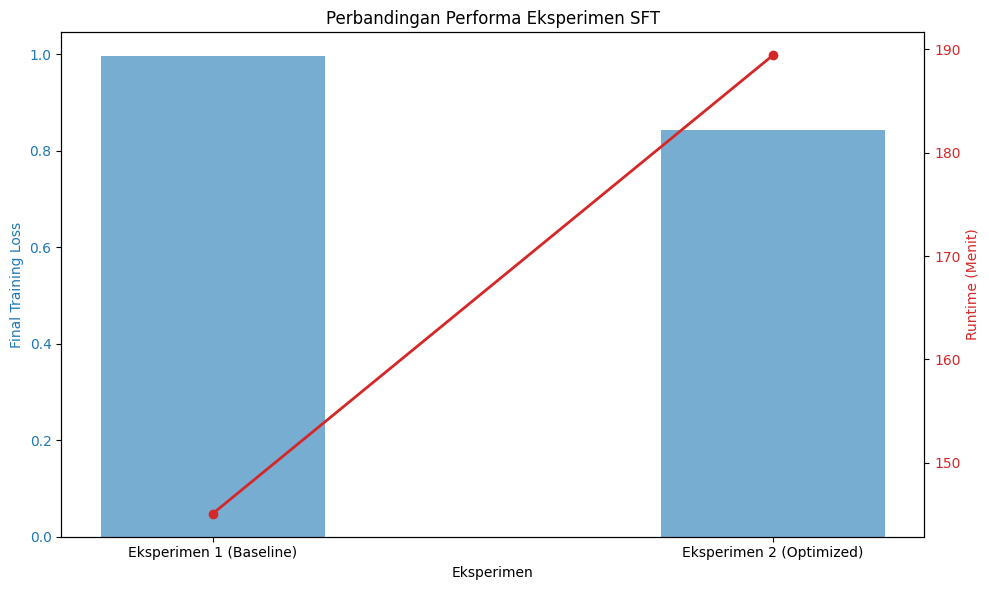

In [20]:
import matplotlib.pyplot as plt

def plot_experiment_comparison(metrics_1, metrics_2):
    """
    Menghasilkan visualisasi komparatif antara Eksperimen 1 dan Eksperimen 2.
    Membantu dalam pengambilan keputusan model terbaik untuk tahap deployment.
    """
    # Data untuk visualisasi
    experiments = ['Eksperimen 1 (Baseline)', 'Eksperimen 2 (Optimized)']
    train_losses = [metrics_1.get('train_loss', 0), metrics_2.get('train_loss', 0)]
    runtimes = [metrics_1.get('train_runtime_minutes', 0), metrics_2.get('train_runtime_minutes', 0)]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Training Loss
    color = 'tab:blue'
    ax1.set_xlabel('Eksperimen')
    ax1.set_ylabel('Final Training Loss', color=color)
    ax1.bar(experiments, train_losses, color=color, alpha=0.6, width=0.4)
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Runtime
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Runtime (Menit)', color=color)
    ax2.plot(experiments, runtimes, color=color, marker='o', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Perbandingan Performa Eksperimen SFT')
    fig.tight_layout()
    plt.show()

# Menampilkan perbandingan hasil
plot_experiment_comparison(metrics_exp1, metrics_exp2)

### **5.5 PENYIMPANAN MODEL KE HUGGING FACE HUB**

In [21]:
def push_model_to_hub(model, tokenizer, repo_id: str):
    """
    Melakukan proses merging adapter LoRA dengan model dasar dan mengunggahnya 
    ke Hugging Face Hub. 
    
    Args:
        model: Objek model yang telah dilatih (dengan adapter).
        tokenizer: Tokenizer yang telah dikalibrasi.
        repo_id (str): Identitas repositori (format: 'username/repo-name').
    """
    print(f"[SYSTEM] Memulai proses merging dan unggah model ke: {repo_id}")
    
    try:
        # Menggunakan push_to_hub_merged dari Unsloth
        # Metode ini secara otomatis menggabungkan adapter LoRA ke model dasar (FP16)
        model.push_to_hub_merged(
            repo_id=repo_id,
            tokenizer=tokenizer,
            save_method="merged_16bit", # Menggunakan presisi 16-bit untuk akurasi
            token=os.getenv("HF_TOKEN"), # Mengambil token dari environment
            private=True                 # Menjaga privasi repositori
        )
        print(f"[SUCCESS] Model berhasil diunggah ke repositori: {repo_id}")
        
    except Exception as e:
        print(f"[FATAL ERROR] Gagal melakukan push ke Hub: {str(e)}")

# --- EKSEKUSI UNTUK EKSPERIMEN 1 ---
# Repository untuk Eksperimen 1
repo_exp1 = "latief18/legal-llama-3.1-sft-baseline"
push_model_to_hub(trainer_exp1.model, tokenizer, repo_exp1)

# --- EKSEKUSI UNTUK EKSPERIMEN 2 ---
# Repository untuk Eksperimen 2 (Model Terbaik)
repo_exp2 = "latief18/legal-llama-3.1-sft-optimized"
push_model_to_hub(trainer_exp2.model, tokenizer, repo_exp2)

[SYSTEM] Memulai proses merging dan unggah model ke: latief18/legal-llama-3.1-sft-baseline


config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in latief18/legal-llama-3.1-sft-baseline/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...


Unsloth: Merging weights into 16bit:  75%|███████▌  | 3/4 [02:55<00:57, 57.81s/it]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [03:12<00:00, 48.08s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/latief18/legal-llama-3.1-sft-optimized`
[SUCCESS] Model berhasil diunggah ke repositori: latief18/legal-llama-3.1-sft-optimized
